In [1]:
import pandas as pd
import sqlite3

# Load one file first to confirm paths and data look right
admissions = pd.read_csv('../data/admissions.csv')
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [2]:
patients = pd.read_csv('../data/patients.csv')
diagnoses_icd = pd.read_csv('../data/diagnoses_icd.csv')
d_icd_diagnoses = pd.read_csv('../data/d_icd_diagnoses.csv')
labevents = pd.read_csv('../data/labevents.csv')
d_labitems = pd.read_csv('../data/d_labitems.csv')
icustays = pd.read_csv('../data/icustays.csv')

print('admissions:', admissions.shape)
print('patients:', patients.shape)
print('diagnoses_icd:', diagnoses_icd.shape)
print('d_icd_diagnoses:', d_icd_diagnoses.shape)
print('labevents:', labevents.shape)
print('d_labitems:', d_labitems.shape)
print('icustays:', icustays.shape)

admissions: (275, 16)
patients: (100, 6)
diagnoses_icd: (4506, 5)
d_icd_diagnoses: (109775, 3)
labevents: (107727, 16)
d_labitems: (1622, 4)
icustays: (140, 8)


In [3]:
conn = sqlite3.connect('../data/mimic_demo.db')

icustays.to_sql('icustays', conn, if_exists='replace', index=False)
admissions.to_sql('admissions', conn, if_exists='replace', index=False)
patients.to_sql('patients', conn, if_exists='replace', index=False)

query = '''
SELECT
    i.subject_id,
    i.hadm_id,
    i.stay_id,
    i.first_careunit,
    i.los AS icu_los_days,
    a.admittime,
    a.dischtime,
    a.admission_type,
    p.gender,
    p.anchor_age
FROM icustays i
JOIN admissions a ON i.hadm_id = a.hadm_id
JOIN patients p ON i.subject_id = p.subject_id
'''

base = pd.read_sql(query, conn)
print(base.shape)
base.head()

(140, 10)


,subject_id,hadm_id,stay_id,first_careunit,icu_los_days,admittime,dischtime,admission_type,gender,anchor_age
0,10018328,23786647,31269608,Neuro Stepdown,7.702512,2154-04-24 03:15:00,2154-05-03 14:00:00,SURGICAL SAME DAY ADMISSION,F,83
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),5.452662,2169-01-15 04:04:00,2169-01-24 17:20:00,OBSERVATION ADMIT,F,63
2,10020187,26842957,32554129,Neuro Intermediate,0.872685,2170-02-24 00:00:00,2170-02-25 15:00:00,SURGICAL SAME DAY ADMISSION,F,63
3,10012853,27882036,31338022,Trauma SICU (TSICU),3.766725,2176-11-25 21:28:00,2176-12-03 15:24:00,EW EMER.,F,91
4,10020740,25826145,32145159,Trauma SICU (TSICU),1.037106,2150-06-03 20:12:00,2150-06-07 15:05:00,EW EMER.,M,56


In [4]:
adm = admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime']].copy()
adm['admittime'] = pd.to_datetime(adm['admittime'])
adm['dischtime'] = pd.to_datetime(adm['dischtime'])

# Sort so each patient's admissions are in chronological order
adm = adm.sort_values(['subject_id', 'admittime']).reset_index(drop=True)

adm.head(10)

,subject_id,hadm_id,admittime,dischtime
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00
2,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00
3,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00
4,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00
5,10001217,27703517,2157-12-18 16:58:00,2157-12-24 14:55:00
6,10001725,25563031,2110-04-11 15:08:00,2110-04-14 15:00:00
7,10002428,25797028,2155-07-14 19:15:00,2155-07-15 18:37:00
8,10002428,28662225,2156-04-12 14:16:00,2156-04-29 16:26:00
9,10002428,20321825,2156-04-30 20:35:00,2156-05-03 16:36:00


In [5]:
# Prior visit count: how many admissions came before this one, for this patient
adm['prior_visit_count'] = adm.groupby('subject_id').cumcount()

# Find each patient's NEXT admission date (shifted up by one row within each patient)
adm['next_admittime'] = adm.groupby('subject_id')['admittime'].shift(-1)

# How many days between this discharge and the NEXT admission
adm['days_to_next_admit'] = (adm['next_admittime'] - adm['dischtime']).dt.days

# Flag it as a 30-day readmission if that gap is between 0 and 30 days
adm['readmit_30d'] = ((adm['days_to_next_admit'] >= 0) & (adm['days_to_next_admit'] <= 30)).astype(int)

adm.head(10)

,subject_id,hadm_id,admittime,dischtime,prior_visit_count,next_admittime,days_to_next_admit,readmit_30d
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,0,2180-06-26 18:27:00,50.0,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,1,2180-07-23 12:35:00,25.0,1
2,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,2,2180-08-05 23:44:00,11.0,1
3,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,3,NaT,NaN,0
4,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,0,2157-12-18 16:58:00,22.0,1
5,10001217,27703517,2157-12-18 16:58:00,2157-12-24 14:55:00,1,NaT,NaN,0
6,10001725,25563031,2110-04-11 15:08:00,2110-04-14 15:00:00,0,NaT,NaN,0
7,10002428,25797028,2155-07-14 19:15:00,2155-07-15 18:37:00,0,2156-04-12 14:16:00,271.0,0
8,10002428,28662225,2156-04-12 14:16:00,2156-04-29 16:26:00,1,2156-04-30 20:35:00,1.0,1
9,10002428,20321825,2156-04-30 20:35:00,2156-05-03 16:36:00,2,2156-05-11 14:49:00,7.0,1


In [6]:
print('Overall 30-day readmission rate:', round(adm['readmit_30d'].mean() * 100, 1), '%')
print()
print('Prior visit count distribution:')
print(adm['prior_visit_count'].value_counts().sort_index())

Overall 30-day readmission rate: 19.6 %

Prior visit count distribution:
prior_visit_count
0     100
1      48
2      28
3      19
4      17
5      15
6      12
7       8
8       7
9       6
10      3
11      3
12      2
13      1
14      1
15      1
16      1
17      1
18      1
19      1
Name: count, dtype: int64


In [7]:
base = base.merge(
    adm[['hadm_id', 'prior_visit_count', 'readmit_30d']],
    on='hadm_id',
    how='left'
)

print(base.shape)
base[['subject_id', 'hadm_id', 'icu_los_days', 'prior_visit_count', 'readmit_30d']].head(8)

(140, 12)


,subject_id,hadm_id,icu_los_days,prior_visit_count,readmit_30d
0,10018328,23786647,7.702512,1,0
1,10020187,24104168,5.452662,0,0
2,10020187,26842957,0.872685,1,0
3,10012853,27882036,3.766725,3,0
4,10020740,25826145,1.037106,1,0
5,10039708,23819016,1.837685,2,0
6,10020306,23052851,3.198472,2,0
7,10019568,28710730,0.815417,0,0


In [8]:
primary_dx = diagnoses_icd[diagnoses_icd['seq_num'] == 1].copy()

primary_dx = primary_dx.merge(
    d_icd_diagnoses,
    on=['icd_code', 'icd_version'],
    how='left'
)

print(primary_dx.shape)
primary_dx[['hadm_id', 'icd_code', 'icd_version', 'long_title']].head(10)

(275, 6)


,hadm_id,icd_code,icd_version,long_title
0,22580999,41401,9,Coronary atherosclerosis of native coronary ar...
1,22995465,0388,9,Other specified septicemias
2,28324362,4240,9,Mitral valve disorders
3,23300884,99859,9,Other postoperative infection
4,28479513,85221,9,Subdural hemorrhage following injury without m...
5,24597018,3240,9,Intracranial abscess
6,24547356,S0262XA,10,"Fracture of subcondylar process of mandible, i..."
7,20044587,41401,9,Coronary atherosclerosis of native coronary ar...
8,25926192,41401,9,Coronary atherosclerosis of native coronary ar...
9,22342963,I2510,10,Atherosclerotic heart disease of native corona...


In [9]:
def categorize_icd(icd_code, icd_version):
    code = str(icd_code).strip()
    
    if icd_version == 9:
        # ICD-9 codes are numeric. MIMIC stores them WITHOUT the decimal point,
        # e.g. "41401" actually means "414.01" -- so we only care about the first 3 digits
        try:
            num = int(code[:3])
        except ValueError:
            return 'Other'
        
        if 390 <= num <= 459:
            return 'Cardiac'
        if 800 <= num <= 999:
            return 'Injury/Trauma'
        return 'Other'
    
    return 'Other'  # we'll handle ICD-10 next

# Quick test
test_codes = [('41401', 9), ('80707', 9), ('25000', 9)]
for code, version in test_codes:
    print(code, '->', categorize_icd(code, version))

41401 -> Cardiac
80707 -> Injury/Trauma
25000 -> Other


In [10]:
def categorize_icd(icd_code, icd_version):
    code = str(icd_code).strip()
    
    if icd_version == 9:
        if code.startswith('V') or code.startswith('E'):
            return 'Other/Supplementary'
        try:
            num = int(code[:3])
        except ValueError:
            return 'Other/Supplementary'
        
        if 1 <= num <= 139: return 'Infectious'
        if 140 <= num <= 239: return 'Neoplasm/Cancer'
        if 240 <= num <= 279: return 'Endocrine/Metabolic'
        if 280 <= num <= 289: return 'Blood'
        if 290 <= num <= 319: return 'Mental/Behavioral'
        if 320 <= num <= 389: return 'Neuro'
        if 390 <= num <= 459: return 'Cardiac'
        if 460 <= num <= 519: return 'Respiratory'
        if 520 <= num <= 579: return 'GI/Digestive'
        if 580 <= num <= 629: return 'Renal/Genitourinary'
        if 630 <= num <= 679: return 'Pregnancy'
        if 680 <= num <= 709: return 'Skin'
        if 710 <= num <= 739: return 'Musculoskeletal'
        if 740 <= num <= 759: return 'Congenital'
        if 760 <= num <= 779: return 'Perinatal'
        if 780 <= num <= 799: return 'Symptoms/Ill-defined'
        if 800 <= num <= 999: return 'Injury/Trauma'
        return 'Other/Supplementary'
    
    elif icd_version == 10:
        letter = code[0]
        try:
            num = int(code[1:3])
        except ValueError:
            num = 0
        
        if letter in 'AB': return 'Infectious'
        if letter == 'C' or (letter == 'D' and num <= 49): return 'Neoplasm/Cancer'
        if letter == 'D' and num >= 50: return 'Blood'
        if letter == 'E': return 'Endocrine/Metabolic'
        if letter == 'F': return 'Mental/Behavioral'
        if letter == 'G': return 'Neuro'
        if letter == 'H' and num <= 59: return 'Eye'
        if letter == 'H' and num >= 60: return 'Ear'
        if letter == 'I': return 'Cardiac'
        if letter == 'J': return 'Respiratory'
        if letter == 'K': return 'GI/Digestive'
        if letter == 'L': return 'Skin'
        if letter == 'M': return 'Musculoskeletal'
        if letter == 'N': return 'Renal/Genitourinary'
        if letter == 'O': return 'Pregnancy'
        if letter == 'P': return 'Perinatal'
        if letter == 'Q': return 'Congenital'
        if letter == 'R': return 'Symptoms/Ill-defined'
        if letter in 'ST': return 'Injury/Trauma'
        if letter in 'VWXY': return 'External Cause'
        if letter == 'Z': return 'Health Status/Other'
        return 'Other/Supplementary'
    
    return 'Unknown'

# Apply it to every row
primary_dx['dx_category'] = primary_dx.apply(
    lambda row: categorize_icd(row['icd_code'], row['icd_version']),
    axis=1
)

primary_dx['dx_category'].value_counts()

dx_category
Cardiac                 67
Injury/Trauma           35
GI/Digestive            33
Neoplasm/Cancer         24
Infectious              22
Respiratory             18
Symptoms/Ill-defined    18
Mental/Behavioral       15
Endocrine/Metabolic     13
Renal/Genitourinary     10
Neuro                    8
Other/Supplementary      3
Skin                     3
Blood                    3
Health Status/Other      2
Musculoskeletal          1
Name: count, dtype: int64

In [11]:
base = base.merge(
    primary_dx[['hadm_id', 'icd_code', 'long_title', 'dx_category']],
    on='hadm_id',
    how='left'
)

print(base.shape)
print()
print('Missing dx_category:', base['dx_category'].isna().sum())
base[['hadm_id', 'icu_los_days', 'dx_category', 'readmit_30d']].head(8)

(140, 15)

Missing dx_category: 0


,hadm_id,icu_los_days,dx_category,readmit_30d
0,23786647,7.702512,Cardiac,0
1,24104168,5.452662,Cardiac,0
2,26842957,0.872685,Cardiac,0
3,27882036,3.766725,Cardiac,0
4,25826145,1.037106,GI/Digestive,0
5,23819016,1.837685,Infectious,0
6,23052851,3.198472,Endocrine/Metabolic,0
7,28710730,0.815417,Injury/Trauma,0


In [12]:
lab_ids = {
    50912: 'creatinine',
    51301: 'wbc',
    51222: 'hemoglobin',
    50983: 'sodium',
    50931: 'glucose',
    51006: 'bun',
}

# Filter labevents down to just these 6 tests
key_labs = labevents[labevents['itemid'].isin(lab_ids.keys())].copy()
key_labs['charttime'] = pd.to_datetime(key_labs['charttime'])

print(key_labs.shape)
key_labs['itemid'].value_counts()

(17242, 16)


itemid
50983    3007
50912    3003
51006    2974
51222    2787
51301    2760
50931    2711
Name: count, dtype: int64

In [14]:
# Bring in each admission's admittime so we can compare
adm_times = admissions[['hadm_id', 'admittime']].copy()
adm_times['admittime'] = pd.to_datetime(adm_times['admittime'])

key_labs = key_labs.merge(adm_times, on='hadm_id', how='left')

# Keep only lab results drawn on or after the admission time
key_labs_after_admit = key_labs[key_labs['charttime'] >= key_labs['admittime']]

# For each admission + lab type, keep only the EARLIEST result
first_labs = (
    key_labs_after_admit
    .sort_values('charttime')
    .groupby(['hadm_id', 'itemid'])
    .first()
    .reset_index()
)

print(first_labs.shape)
first_labs[['hadm_id', 'itemid', 'charttime', 'valuenum']].head(10)

(1445, 17)


,hadm_id,itemid,charttime,valuenum
0,20044587.0,50912,2113-08-25 12:45:00,1.0
1,20044587.0,50931,2113-08-26 03:15:00,76.0
2,20044587.0,50983,2113-08-25 12:45:00,145.0
3,20044587.0,51006,2113-08-25 12:45:00,23.0
4,20044587.0,51222,2113-08-25 12:45:00,10.8
5,20044587.0,51301,2113-08-25 12:45:00,9.7
6,20093566.0,50912,2143-09-27 05:10:00,9.7
7,20093566.0,50931,2143-09-27 05:10:00,67.0
8,20093566.0,50983,2143-09-27 05:10:00,141.0
9,20093566.0,51006,2143-09-27 05:10:00,51.0


In [15]:
first_labs['lab_name'] = first_labs['itemid'].map(lab_ids)

labs_wide = first_labs.pivot(index='hadm_id', columns='lab_name', values='valuenum').reset_index()

print(labs_wide.shape)
labs_wide.head(8)

(244, 7)


lab_name,hadm_id,bun,creatinine,glucose,hemoglobin,sodium,wbc
0,20044587.0,23.0,1.0,76.0,10.8,145.0,9.7
1,20093566.0,51.0,9.7,67.0,7.6,141.0,6.7
2,20192635.0,26.0,1.3,361.0,11.2,135.0,5.4
3,20199380.0,11.0,0.6,116.0,11.8,136.0,11.9
4,20214994.0,9.0,0.7,96.0,10.0,142.0,2.5
5,20285402.0,8.0,0.4,98.0,10.4,136.0,12.5
6,20291550.0,11.0,0.7,246.0,12.3,138.0,12.5
7,20297618.0,16.0,0.8,119.0,15.5,138.0,7.7


In [16]:
base = base.merge(labs_wide, on='hadm_id', how='left')

print(base.shape)
print()
print('Missing values per column:')
print(base.isna().sum())

(140, 21)

Missing values per column:
subject_id           0
hadm_id              0
stay_id              0
first_careunit       0
icu_los_days         0
admittime            0
dischtime            0
admission_type       0
gender               0
anchor_age           0
prior_visit_count    0
readmit_30d          0
icd_code             0
long_title           0
dx_category          0
bun                  0
creatinine           0
glucose              0
hemoglobin           0
sodium               0
wbc                  0
dtype: int64


In [17]:
base.to_csv('../output/master_table.csv', index=False)
base.to_pickle('../notebook/master_table.pkl')

print('Saved. Final table:')
base.head()

Saved. Final table:


,subject_id,hadm_id,stay_id,first_careunit,icu_los_days,admittime,dischtime,admission_type,gender,anchor_age,...,readmit_30d,icd_code,long_title,dx_category,bun,creatinine,glucose,hemoglobin,sodium,wbc
0,10018328,23786647,31269608,Neuro Stepdown,7.702512,2154-04-24 03:15:00,2154-05-03 14:00:00,SURGICAL SAME DAY ADMISSION,F,83,...,0,I671,"Cerebral aneurysm, nonruptured",Cardiac,9.0,0.6,143.0,8.8,140.0,17.8
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),5.452662,2169-01-15 04:04:00,2169-01-24 17:20:00,OBSERVATION ADMIT,F,63,...,0,I6032,Nontraumatic subarachnoid hemorrhage from left...,Cardiac,11.0,0.5,114.0,11.9,139.0,7.7
2,10020187,26842957,32554129,Neuro Intermediate,0.872685,2170-02-24 00:00:00,2170-02-25 15:00:00,SURGICAL SAME DAY ADMISSION,F,63,...,0,I671,"Cerebral aneurysm, nonruptured",Cardiac,10.0,0.5,97.0,12.0,143.0,6.1
3,10012853,27882036,31338022,Trauma SICU (TSICU),3.766725,2176-11-25 21:28:00,2176-12-03 15:24:00,EW EMER.,F,91,...,0,I82622,Acute embolism and thrombosis of deep veins of...,Cardiac,16.0,0.9,113.0,9.3,143.0,5.2
4,10020740,25826145,32145159,Trauma SICU (TSICU),1.037106,2150-06-03 20:12:00,2150-06-07 15:05:00,EW EMER.,M,56,...,0,5770,Acute pancreatitis,GI/Digestive,14.0,0.9,196.0,10.1,140.0,6.9


In [18]:
print('ICU Length of Stay (days):')
print(base['icu_los_days'].describe())
print()
print('30-day readmission rate:', round(base['readmit_30d'].mean() * 100, 1), '%')
print('Number of readmissions:', base['readmit_30d'].sum(), 'out of', len(base), 'ICU stays')

ICU Length of Stay (days):
count    140.000000
mean       3.679379
std        3.896354
min        0.023727
25%        1.170663
50%        2.155093
75%        4.907749
max       20.528681
Name: icu_los_days, dtype: float64

30-day readmission rate: 17.9 %
Number of readmissions: 25 out of 140 ICU stays


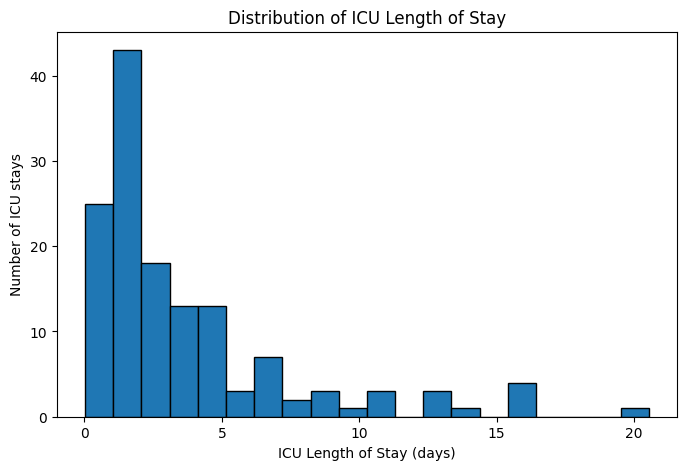

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(base['icu_los_days'], bins=20, edgecolor='black')
plt.xlabel('ICU Length of Stay (days)')
plt.ylabel('Number of ICU stays')
plt.title('Distribution of ICU Length of Stay')
plt.show()

In [20]:
los_by_category = base.groupby('dx_category')['icu_los_days'].agg(['count', 'median', 'mean']).sort_values('median', ascending=False)
los_by_category

,count,median,mean
dx_category,,,
Blood,2,9.533362,9.533362
Infectious,18,4.775231,4.796967
Respiratory,13,3.349803,4.940962
Symptoms/Ill-defined,3,3.267720,3.737311
Injury/Trauma,19,2.471169,4.552117
Other/Supplementary,1,2.110532,2.110532
Neuro,6,2.079236,2.878385
Cardiac,41,1.999329,3.089847
Neoplasm/Cancer,13,1.871586,3.203226


<Figure size 1000x600 with 0 Axes>

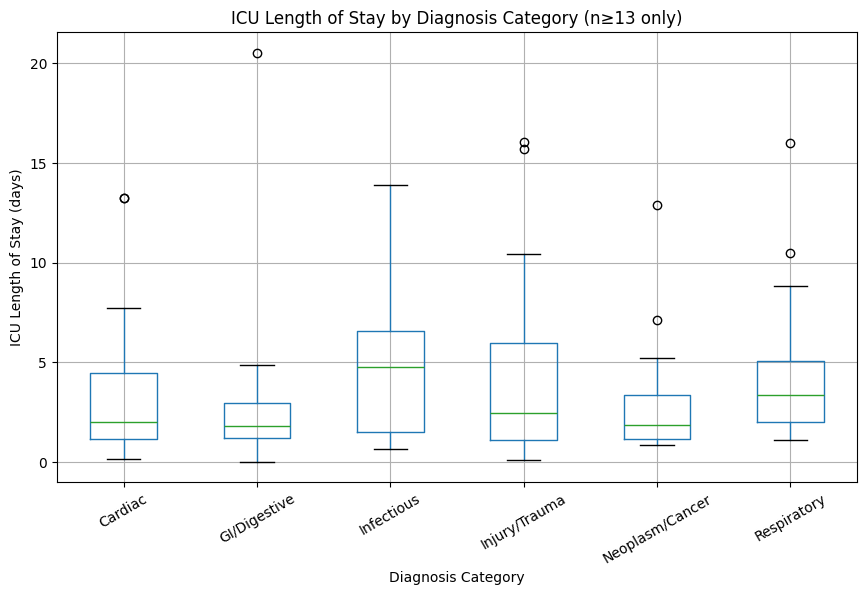

In [21]:
reliable_categories = ['Cardiac', 'Injury/Trauma', 'Infectious', 'GI/Digestive', 'Respiratory', 'Neoplasm/Cancer']
plot_data = base[base['dx_category'].isin(reliable_categories)]

plt.figure(figsize=(10, 6))
plot_data.boxplot(column='icu_los_days', by='dx_category', figsize=(10,6))
plt.xlabel('Diagnosis Category')
plt.ylabel('ICU Length of Stay (days)')
plt.title('ICU Length of Stay by Diagnosis Category (n≥13 only)')
plt.suptitle('')
plt.xticks(rotation=30)
plt.show()

In [22]:
from scipy import stats

groups = [plot_data[plot_data['dx_category'] == cat]['icu_los_days'] for cat in reliable_categories]

h_stat, p_value = stats.kruskal(*groups)

print('Kruskal-Wallis H-statistic:', round(h_stat, 3))
print('p-value:', round(p_value, 4))

Kruskal-Wallis H-statistic: 6.528
p-value: 0.2581


In [23]:
lab_cols = ['bun', 'creatinine', 'glucose', 'hemoglobin', 'sodium', 'wbc']

correlations = base[lab_cols + ['icu_los_days']].corr()['icu_los_days'].drop('icu_los_days')
correlations.sort_values(ascending=False)

bun           0.149976
creatinine    0.041499
glucose       0.008579
hemoglobin   -0.000289
wbc          -0.006133
sodium       -0.083619
Name: icu_los_days, dtype: float64

In [24]:
readmit_yes = base[base['readmit_30d'] == 1]['prior_visit_count']
readmit_no = base[base['readmit_30d'] == 0]['prior_visit_count']

print('Median prior visits, READMITTED group:', readmit_yes.median())
print('Median prior visits, NOT readmitted group:', readmit_no.median())
print()

u_stat, p_value = stats.mannwhitneyu(readmit_yes, readmit_no)
print('Mann-Whitney U p-value:', round(p_value, 4))

Median prior visits, READMITTED group: 1.0
Median prior visits, NOT readmitted group: 0.0

Mann-Whitney U p-value: 0.1946


In [25]:
contingency = pd.crosstab(plot_data['dx_category'], plot_data['readmit_30d'])
print(contingency)
print()

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print('Chi-square p-value:', round(p_value, 4))

readmit_30d       0  1
dx_category           
Cardiac          36  5
GI/Digestive     13  2
Infectious       15  3
Injury/Trauma    15  4
Neoplasm/Cancer  13  0
Respiratory       7  6

Chi-square p-value: 0.0402


In [26]:
import numpy as np

expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print('Expected counts per cell (should mostly be 5+):')
print(expected_df.round(1))

Expected counts per cell (should mostly be 5+):
readmit_30d         0    1
dx_category               
Cardiac          34.1  6.9
GI/Digestive     12.5  2.5
Infectious       15.0  3.0
Injury/Trauma    15.8  3.2
Neoplasm/Cancer  10.8  2.2
Respiratory      10.8  2.2


In [27]:
tableau_export = base[[
    'subject_id', 'hadm_id', 'stay_id', 'dx_category',
    'icu_los_days', 'readmit_30d', 'prior_visit_count',
    'gender', 'anchor_age', 'admission_type', 'first_careunit',
    'bun', 'creatinine', 'glucose', 'hemoglobin', 'sodium', 'wbc'
]].copy()

tableau_export.to_csv('../output/tableau_main_export.csv', index=False)

print(tableau_export.shape)
tableau_export.head()

(140, 17)


,subject_id,hadm_id,stay_id,dx_category,icu_los_days,readmit_30d,prior_visit_count,gender,anchor_age,admission_type,first_careunit,bun,creatinine,glucose,hemoglobin,sodium,wbc
0,10018328,23786647,31269608,Cardiac,7.702512,0,1,F,83,SURGICAL SAME DAY ADMISSION,Neuro Stepdown,9.0,0.6,143.0,8.8,140.0,17.8
1,10020187,24104168,37509585,Cardiac,5.452662,0,0,F,63,OBSERVATION ADMIT,Neuro Surgical Intensive Care Unit (Neuro SICU),11.0,0.5,114.0,11.9,139.0,7.7
2,10020187,26842957,32554129,Cardiac,0.872685,0,1,F,63,SURGICAL SAME DAY ADMISSION,Neuro Intermediate,10.0,0.5,97.0,12.0,143.0,6.1
3,10012853,27882036,31338022,Cardiac,3.766725,0,3,F,91,EW EMER.,Trauma SICU (TSICU),16.0,0.9,113.0,9.3,143.0,5.2
4,10020740,25826145,32145159,GI/Digestive,1.037106,0,1,M,56,EW EMER.,Trauma SICU (TSICU),14.0,0.9,196.0,10.1,140.0,6.9


In [28]:
category_summary = base.groupby('dx_category').agg(
    n_patients=('hadm_id', 'count'),
    median_los=('icu_los_days', 'median'),
    mean_los=('icu_los_days', 'mean'),
    readmit_rate=('readmit_30d', 'mean')
).reset_index()

category_summary['readmit_rate_pct'] = (category_summary['readmit_rate'] * 100).round(1)
category_summary = category_summary.sort_values('n_patients', ascending=False)

category_summary.to_csv('../output/category_summary.csv', index=False)

category_summary

,dx_category,n_patients,median_los,mean_los,readmit_rate,readmit_rate_pct
1,Cardiac,41,1.999329,3.089847,0.121951,12.2
5,Injury/Trauma,19,2.471169,4.552117,0.210526,21.1
4,Infectious,18,4.775231,4.796967,0.166667,16.7
3,GI/Digestive,15,1.788611,3.261618,0.133333,13.3
8,Neoplasm/Cancer,13,1.871586,3.203226,0.000000,0.0
11,Respiratory,13,3.349803,4.940962,0.461538,46.2
9,Neuro,6,2.079236,2.878385,0.333333,33.3
2,Endocrine/Metabolic,5,1.135231,1.475127,0.000000,0.0
6,Mental/Behavioral,3,0.678970,1.017704,0.333333,33.3
12,Symptoms/Ill-defined,3,3.267720,3.737311,0.333333,33.3


In [29]:
def bin_prior_visits(n):
    if n == 0:
        return '0 (first visit)'
    elif n <= 2:
        return '1-2'
    elif n <= 5:
        return '3-5'
    else:
        return '6+'

base['prior_visit_bin'] = base['prior_visit_count'].apply(bin_prior_visits)

prior_visit_summary = base.groupby('prior_visit_bin').agg(
    n_patients=('hadm_id', 'count'),
    readmit_rate=('readmit_30d', 'mean')
).reset_index()

prior_visit_summary['readmit_rate_pct'] = (prior_visit_summary['readmit_rate'] * 100).round(1)

# Put bins in logical order rather than alphabetical
bin_order = ['0 (first visit)', '1-2', '3-5', '6+']
prior_visit_summary['prior_visit_bin'] = pd.Categorical(prior_visit_summary['prior_visit_bin'], categories=bin_order, ordered=True)
prior_visit_summary = prior_visit_summary.sort_values('prior_visit_bin')

prior_visit_summary.to_csv('../output/prior_visit_summary.csv', index=False)

prior_visit_summary

,prior_visit_bin,n_patients,readmit_rate,readmit_rate_pct
0,0 (first visit),80,0.150000,15.0
1,1-2,42,0.190476,19.0
2,3-5,5,0.000000,0.0
3,6+,13,0.384615,38.5
